In [1]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CS667 – Practical Data Science | Spring 2026
## Project #1: Exploratory Data Analysis on Retail Sales Data
**Student:** [Your Name] | **Professor:** Prof. Sarbanes
**Dataset:** retail_sales.xlsx (Kaggle Retail Sales Dataset)

---
### Notebook Structure
| Section | Title |
|---------|-------|
| 0 | Setup & Imports |
| 1 | Data Loading & Quality Check |
| 2 | Feature Engineering |
| 3 | Interactive Univariate Explorer |
| 4 | Interactive Bivariate Explorer |
| 5 | Time-Series & Seasonality Dashboard |
| 6 | Customer Segmentation Explorer |
| 7 | Outlier & Anomaly Detection |
| 8 | Feature Importance & Encoding |
| 9 | Business Insights & Recommendations |
"""))



# CS667 – Practical Data Science | Spring 2026
## Project #1: Exploratory Data Analysis on Retail Sales Data
**Student:** [Your Name] | **Professor:** Prof. Sarbanes
**Dataset:** retail_sales.xlsx (Kaggle Retail Sales Dataset)

---
### Notebook Structure
| Section | Title |
|---------|-------|
| 0 | Setup & Imports |
| 1 | Data Loading & Quality Check |
| 2 | Feature Engineering |
| 3 | Interactive Univariate Explorer |
| 4 | Interactive Bivariate Explorer |
| 5 | Time-Series & Seasonality Dashboard |
| 6 | Customer Segmentation Explorer |
| 7 | Outlier & Anomaly Detection |
| 8 | Feature Importance & Encoding |
| 9 | Business Insights & Recommendations |


In [2]:
!pip install pandas matplotlib seaborn plotly scikit-learn ipywidgets openpyxl anywidget


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Fnuas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# --- [Section 0.2: All Imports & Colab Widget Fix] ---
# Run this cell FIRST every session. Enables interactive widgets in Colab.

# Colab-specific: enables custom widget rendering
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("✅ Colab widget manager enabled")
except ImportError:
    print("✅ Running in local Jupyter — widgets work natively")

# Core data libraries
import pandas as pd
import numpy as np
from scipy import stats
from scipy.special import boxcox1p

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
from IPython.display import display, Markdown

# Encoding & ML utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

# # quick test for FigureWidget compatibility
# try:
#     _ = go.FigureWidget()
#     print("✅ FigureWidget class is present")
# except Exception as e:
#     print("⚠️ FigureWidget not available – you may need to restart kernel and enable nbextensions")
#     print(e)

# Ensure necessary Jupyter extensions are enabled for interactive widgets
# Note: manual kernel restart may still be required.
# import sys
# if 'google.colab' not in sys.modules:
#     get_ipython().run_line_magic('pip', 'install nbformat')  # already present
#     # enable widget nbextension if jupyter command exists
#     try:
#         get_ipython().system('jupyter nbextension enable --py widgetsnbextension --sys-prefix')
#         get_ipython().system('jupyter nbextension enable --py plotlywidget --sys-prefix')
#         print("✅ Widget & plotly nbextensions enable command executed (no error).")
#     except Exception as e:
#         print("⚠️ Could not run nbextension enable command; run manually in shell:")
#         print("    jupyter nbextension enable --py plotlywidget --sys-prefix")


✅ Running in local Jupyter — widgets work natively
✅ All libraries loaded successfully
✅ FigureWidget class is present
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Fnuas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
lab

✅ Widget & plotly nbextensions enable command executed (no error).


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [4]:
# install anywidget needed for Plotly FigureWidget (one‑time)
# %pip magic works reliably inside notebooks and in virtualenvs.
try:
    import anywidget
except ImportError:
    get_ipython().run_line_magic('pip', 'install anywidget')



In [5]:

from IPython.display import Markdown, display

display(Markdown("""
**Note:** `anywidget` has been installed. Please **restart the notebook kernel**
and then re-run the import cell (Section 0.2) before using the FigureWidget demo
below. This is required for the new package to be available.
"""))



**Note:** `anywidget` has been installed. Please **restart the notebook kernel**
and then re-run the import cell (Section 0.2) before using the FigureWidget demo
below. This is required for the new package to be available.


In [6]:

# ***NOTE***: To activate the newly installed `anywidget` package you must
# manually restart the notebook kernel (use the toolbar button or Kernel menu),
# then rerun the import cell (Section 0.2) before executing the FigureWidget demo.
# The automated restart call raised an AttributeError earlier, so we avoid it.


In [7]:
# --- [Section 1.1: Load Dataset] ---
# Load the retail sales Excel file into a pandas DataFrame.
# Adjust the path if running locally vs Colab.

df = pd.read_excel('retail_sales.xlsx')   # Change path if needed

# Quick sanity check
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head()


✅ Dataset loaded: 1000 rows × 9 columns
Columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [8]:
# df = df.drop(columns=['Customer ID'])

In [9]:
# --- [Section 1.2: Data Structure Overview] ---
# Understanding the shape, data types, and a random sample is always
# the first step — it tells you what kind of cleaning you'll need.

print("=" * 50)
print(f"SHAPE      : {df.shape}")
print(f"COLUMNS    : {df.columns.tolist()}")
print("=" * 50)
print("\nDATA TYPES:")
print(df.dtypes)
print("\nRANDOM SAMPLE (5 rows):")
display(df.sample(5, random_state=42))


SHAPE      : (1000, 9)
COLUMNS    : ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

DATA TYPES:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

RANDOM SAMPLE (5 rows):


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
521,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
737,738,2023-04-25,CUST738,Male,41,Clothing,2,50,100
740,741,2023-11-30,CUST741,Male,48,Clothing,1,300,300
660,661,2023-07-16,CUST661,Female,44,Clothing,4,25,100
411,412,2023-09-16,CUST412,Female,19,Electronics,4,500,2000


In [10]:
# --- [Section 1.3: Missing Values & Duplicate Check] ---
# Critical QC step. Missing data and duplicates can silently corrupt
# downstream statistics and ML models.

print("MISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
qc = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(qc[qc['Missing Count'] > 0] if qc['Missing Count'].sum() > 0 else "✅ No missing values")

# --- [Optional] Handling missing data demonstration ---
# If there were missing values in critical columns, we could impute them.
# This example uses simple mean imputation but could be replaced with
# model-based (IterativeImputer) or domain-specific logic.
if qc['Missing Count'].sum() > 0:
    from sklearn.impute import SimpleImputer
    num_cols = df.select_dtypes(include='number').columns
    imputer = SimpleImputer(strategy='mean')
    df[num_cols] = imputer.fit_transform(df[num_cols])
    print("✅ Imputed numeric missing values with column means")
    # For categorical, one could use strategy='most_frequent' or a predictive model
    cat_cols = df.select_dtypes(include='object').columns
    if len(cat_cols) > 0:
        imp_cat = SimpleImputer(strategy='most_frequent')
        df[cat_cols] = imp_cat.fit_transform(df[cat_cols])
        print("✅ Imputed categorical missing values with most frequent category")
    # Re-check
    missing = df.isnull().sum()
    display(pd.DataFrame({'Post-Impute Missing': missing}))

print(f"\nDUPLICATE ROWS: {df.duplicated().sum()}")
print(f"DUPLICATE Transaction IDs: {df['Transaction ID'].duplicated().sum()}")


MISSING VALUES:


'✅ No missing values'


DUPLICATE ROWS: 0
DUPLICATE Transaction IDs: 0


In [11]:
# --- [Section 1.4: Descriptive Statistics] ---
# .describe() reveals central tendency, spread, and range for numerics.
# Watch for: min=0 (possible errors), max outliers, std >> mean (high variance).

print("NUMERIC COLUMNS:")
display(df.describe().T.round(2))

print("\nCATEGORICAL COLUMNS:")
cat_cols = df.select_dtypes(include='object').columns
# optionally exclude Customer ID since it’s unique and not analytically useful
cat_cols = [c for c in cat_cols if c.lower() != 'customer id']
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())


NUMERIC COLUMNS:


,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000256,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632



CATEGORICAL COLUMNS:

Gender (2 unique):
Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category (3 unique):
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [12]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 What to look for in descriptive stats:
- **Age**: Check min/max for unrealistic values (e.g., age < 10 or > 100)
- **Total Amount vs Price per Unit × Quantity**: These should match — validate the relationship
- **Gender / Product Category**: Are categories balanced or heavily skewed? Imbalance affects segmentation.
- **Price per Unit**: Large std relative to mean suggests multiple product price tiers
"""))



#### 📝 What to look for in descriptive stats:
- **Age**: Check min/max for unrealistic values (e.g., age < 10 or > 100)
- **Total Amount vs Price per Unit × Quantity**: These should match — validate the relationship
- **Gender / Product Category**: Are categories balanced or heavily skewed? Imbalance affects segmentation.
- **Price per Unit**: Large std relative to mean suggests multiple product price tiers


In [13]:
# --- [Section 1.5: Business Logic Validation] ---
# Total Amount should equal Price per Unit × Quantity.
# Any mismatch indicates dirty data or calculation errors.

df['Computed_Total'] = df['Price per Unit'] * df['Quantity']
mismatch = df[df['Computed_Total'] != df['Total Amount']]

print(f"✅ Total Amount = Price × Quantity for all rows: {len(mismatch) == 0}")
if len(mismatch) > 0:
    print(f"⚠️  {len(mismatch)} mismatches found:")
    display(mismatch.head())

# Drop the helper column
df.drop(columns=['Computed_Total'], inplace=True)


✅ Total Amount = Price × Quantity for all rows: True


In [14]:
# --- [Section 2.1: Time-Based Feature Extraction] ---
# Extracting temporal components from the Date column.
# These features capture seasonality, day-of-week effects, and quarterly patterns —
# all critical for sales forecasting models.

df_feat = df.copy()

df_feat['Year']        = df_feat['Date'].dt.year
    
df_feat['Month']       = df_feat['Date'].dt.month
    
df_feat['Month_Name']  = df_feat['Date'].dt.strftime('%B')
    
df_feat['Quarter']     = df_feat['Date'].dt.quarter
    
df_feat['Day_of_Week'] = df_feat['Date'].dt.dayofweek          # 0=Monday, 6=Sunday
    
df_feat['Day_Name']    = df_feat['Date'].dt.strftime('%A')
    
df_feat['Week_of_Year']= df_feat['Date'].dt.isocalendar().week.astype(int)
    
df_feat['Is_Weekend']  = df_feat['Day_of_Week'].isin([5, 6]).astype(int)

print("✅ Time features added:")
print(df_feat[['Date','Year','Month','Quarter','Day_Name','Is_Weekend']].head())


✅ Time features added:
        Date  Year  Month  Quarter  Day_Name  Is_Weekend
0 2023-11-24  2023     11        4    Friday           0
1 2023-02-27  2023      2        1    Monday           0
2 2023-01-13  2023      1        1    Friday           0
3 2023-05-21  2023      5        2    Sunday           1
4 2023-05-06  2023      5        2  Saturday           1


In [15]:
# --- [Section 2.2: Age Group Segmentation Feature] ---
# Binning continuous age into groups enables categorical segmentation analysis.
# Groups aligned with common retail marketing segments (Gen Z, Millennial, etc.)

age_bins   = [0, 24, 34, 44, 54, 100]
age_labels = ['18–24 (Gen Z)', '25–34 (Millennial)', '35–44 (Gen X)', '45–54 (Boomer)', '55+ (Senior)']

df_feat['Age_Group'] = pd.cut(df_feat['Age'], bins=age_bins, labels=age_labels)

print("Age Group distribution:")
print(df_feat['Age_Group'].value_counts().sort_index())


Age Group distribution:
Age_Group
18–24 (Gen Z)         149
25–34 (Millennial)    203
35–44 (Gen X)         207
45–54 (Boomer)        225
55+ (Senior)          216
Name: count, dtype: int64


In [16]:
# --- [Section 2.3: Rolling Averages — Time-Decaying Feature] ---
# Rolling averages smooth out noise and capture recent trends.
# 7-day captures weekly rhythm; 30-day captures monthly momentum.
# These are core features in sales forecasting models (ARIMA, LSTM, etc.)

daily_sales = (
    df_feat.groupby('Date')['Total Amount']
    .sum()
    .reset_index()
    .sort_values('Date')
    .set_index('Date')
)

daily_sales['Rolling_7D']  = daily_sales['Total Amount'].rolling(window=7,  min_periods=1).mean()
daily_sales['Rolling_30D'] = daily_sales['Total Amount'].rolling(window=30, min_periods=1).mean()

print("✅ Rolling averages computed on daily aggregated sales")
print(daily_sales.tail(5))


✅ Rolling averages computed on daily aggregated sales
            Total Amount   Rolling_7D  Rolling_30D
Date                                              
2023-12-27           700  1018.571429  1394.666667
2023-12-28          2075  1272.142857  1450.833333
2023-12-29          3400  1615.000000  1503.333333
2023-12-31            50  1357.857143  1489.666667
2024-01-01          1530  1547.857143  1537.000000


In [17]:
# --- [Section 2.4: Target Encoding — Product Category] ---
# Target encoding replaces a categorical label with the mean of the target variable
# (Total Amount) for that category. Better than one-hot encoding when categories
# have many levels or have an ordinal relationship with the target.
# NOTE: In a real ML pipeline, fit encoding on TRAIN set only to prevent leakage.

target_enc_map = df_feat.groupby('Product Category')['Total Amount'].mean()
df_feat['ProductCat_TargetEnc'] = df_feat['Product Category'].map(target_enc_map)

print("Target Encoding Map (Product Category → Mean Total Amount):")
print(target_enc_map.round(2))


Target Encoding Map (Product Category → Mean Total Amount):
Product Category
Beauty         467.48
Clothing       443.25
Electronics    458.79
Name: Total Amount, dtype: float64


In [18]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 🧠 Note on Advanced Encoding
In addition to the target encoding used above for `Product Category`, more sophisticated
techniques such as embedding layers in a neural network can capture relationships
among high-cardinality categorical features like `Customer ID` for downstream models.
These embeddings map categories to dense vectors learned during training, often
improving performance on complex tasks such as recommendation or forecasting.
"""))


#### 🧠 Note on Advanced Encoding
In addition to the target encoding used above for `Product Category`, more sophisticated
techniques such as embedding layers in a neural network can capture relationships
among high-cardinality categorical features like `Customer ID` for downstream models.
These embeddings map categories to dense vectors learned during training, often
improving performance on complex tasks such as recommendation or forecasting.


In [19]:
# --- [Section 2.5: Log Transform to Handle Skewness] ---
# Total Amount and Price per Unit may be right-skewed (few very large transactions).
# Log(1+x) compresses the tail, making distributions closer to normal —
# which improves performance of linear models and distance-based algorithms.

for col in ['Total Amount', 'Price per Unit']:
    skew_before = df_feat[col].skew().round(3)
    df_feat[f'Log_{col.replace(" ","_")}'] = np.log1p(df_feat[col])
    skew_after  = df_feat[f'Log_{col.replace(" ","_")}'].skew().round(3)
    print(f"{col}: skew before={skew_before}, skew after={skew_after}")


Total Amount: skew before=1.376, skew after=0.259
Price per Unit: skew before=0.736, skew after=0.378


In [20]:
# --- [Section 2.6: Label Encoding for Gender] ---
# Binary categorical → numeric for ML models.
# Male=1, Female=0 (or use pd.get_dummies for one-hot if needed downstream).

df_feat['Gender_Enc'] = (df_feat['Gender'] == 'Male').astype(int)

print("✅ Gender encoded: Male=1, Female=0")
print(df_feat[['Gender','Gender_Enc']].value_counts())


✅ Gender encoded: Male=1, Female=0
Gender  Gender_Enc
Female  0             510
Male    1             490
Name: count, dtype: int64


In [21]:
# --- [Section 2.7: Final Feature Inventory] ---
# Review all columns now available in df_feat before building dashboards.

print(f"df_feat shape: {df_feat.shape}")
print("\nAll columns:")
for col in df_feat.columns:
    print(f"  {col:35s} | dtype: {df_feat[col].dtype}")


df_feat shape: (1000, 22)

All columns:
  Transaction ID                      | dtype: int64
  Date                                | dtype: datetime64[ns]
  Customer ID                         | dtype: object
  Gender                              | dtype: object
  Age                                 | dtype: int64
  Product Category                    | dtype: object
  Quantity                            | dtype: int64
  Price per Unit                      | dtype: int64
  Total Amount                        | dtype: int64
  Year                                | dtype: int32
  Month                               | dtype: int32
  Month_Name                          | dtype: object
  Quarter                             | dtype: int32
  Day_of_Week                         | dtype: int32
  Day_Name                            | dtype: object
  Week_of_Year                        | dtype: int32
  Is_Weekend                          | dtype: int32
  Age_Group                           | dtype

In [22]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 3: Interactive Univariate Explorer
**Purpose:** Understand the distribution of each individual variable in isolation.
Use the dropdowns below to switch columns and chart types — no code needed.
"""))



## Section 3: Interactive Univariate Explorer
**Purpose:** Understand the distribution of each individual variable in isolation.
Use the dropdowns below to switch columns and chart types — no code needed.


In [23]:
# --- [Section 3.1: Interactive Univariate Explorer Widget] ---
# Dropdowns control: which column to plot, chart type, and whether to show stats.
# Supports both numeric (histogram, box, violin) and categorical (bar, pie) columns.

numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount',
                'Log_Total_Amount', 'Log_Price_per_Unit']
cat_cols     = ['Gender', 'Product Category', 'Day_Name', 'Month_Name',
                'Quarter', 'Age_Group', 'Is_Weekend']
all_cols     = numeric_cols + cat_cols

col_dropdown   = widgets.Dropdown(options=all_cols, value='Total Amount',
                                  description='Column:', style={'description_width':'initial'})
chart_dropdown = widgets.Dropdown(options=['histogram','box','violin','bar','pie'],
                                  value='histogram', description='Chart Type:',
                                  style={'description_width':'initial'})
bins_slider    = widgets.IntSlider(value=30, min=5, max=100, step=5,
                                   description='Bins (histogram):',
                                   style={'description_width':'initial'})
stats_toggle   = widgets.Checkbox(value=True, description='Show Statistics Table')
out            = Output()

def update_univariate(change=None):
    out.clear_output(wait=True)
    col        = col_dropdown.value
    chart_type = chart_dropdown.value
    with out:
        if chart_type == 'histogram' and col in numeric_cols:
            fig = px.histogram(df_feat, x=col, nbins=bins_slider.value,
                               color_discrete_sequence=['#636EFA'],
                               title=f'Distribution of {col}',
                               marginal='box')  # adds a mini boxplot on top
        elif chart_type == 'box':
            fig = px.box(df_feat, y=col, title=f'Box Plot — {col}',
                         color_discrete_sequence=['#EF553B'])
        elif chart_type == 'violin':
            fig = px.violin(df_feat, y=col, box=True, points='outliers',
                            title=f'Violin Plot — {col}',
                            color_discrete_sequence=['#00CC96'])
        elif chart_type == 'bar' and col in cat_cols:
            counts = df_feat[col].value_counts().reset_index()
            counts.columns = [col, 'Count']
            fig = px.bar(counts, x=col, y='Count', title=f'Value Counts — {col}',
                         color='Count', color_continuous_scale='Blues')
        elif chart_type == 'pie' and col in cat_cols:
            counts = df_feat[col].value_counts().reset_index()
            counts.columns = [col, 'Count']
            fig = px.pie(counts, names=col, values='Count', title=f'Share — {col}')
        else:
            print(f"⚠️  '{chart_type}' not applicable for '{col}'. Try 'bar' or 'pie' for categoricals.")
            return
        fig.update_layout(template='plotly_white')
        fig.show()

        if stats_toggle.value and col in numeric_cols:
            s = df_feat[col].describe()
            print(f"\n📊 Stats for '{col}':")
            print(f"  Mean    : {s['mean']:.2f}")
            print(f"  Median  : {df_feat[col].median():.2f}")
            print(f"  Std Dev : {s['std']:.2f}")
            print(f"  Skewness: {df_feat[col].skew():.3f}")
            print(f"  Kurtosis: {df_feat[col].kurtosis():.3f}")
            print(f"  Range   : [{s['min']:.2f}, {s['max']:.2f}]")

# Bind all widgets to the update function
for w in [col_dropdown, chart_dropdown, bins_slider, stats_toggle]:
    w.observe(update_univariate, names='value')

display(VBox([
    HBox([col_dropdown, chart_dropdown]),
    HBox([bins_slider, stats_toggle]),
    out
]))

update_univariate()   # render on load


In [24]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 How to read these charts:
- **Histogram + box on top**: The box shows median (center line), IQR (box), and outliers (dots beyond whiskers)
- **Skewness > 1**: Right-skewed distribution — a few very high-value transactions pulling the mean up. Use log transform.
- **Violin plot**: Wider = more data density at that value. Shows full distribution shape, not just summary.
- **Bar chart for categoricals**: Look for category imbalance — an over-represented category can bias ML models.
"""))



#### 📝 How to read these charts:
- **Histogram + box on top**: The box shows median (center line), IQR (box), and outliers (dots beyond whiskers)
- **Skewness > 1**: Right-skewed distribution — a few very high-value transactions pulling the mean up. Use log transform.
- **Violin plot**: Wider = more data density at that value. Shows full distribution shape, not just summary.
- **Bar chart for categoricals**: Look for category imbalance — an over-represented category can bias ML models.


In [25]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 4: Interactive Bivariate Explorer
**Purpose:** Explore relationships between two variables. Add a color/hue dimension
to spot group-level differences (e.g., does Gender affect spending per category?).
"""))



## Section 4: Interactive Bivariate Explorer
**Purpose:** Explore relationships between two variables. Add a color/hue dimension
to spot group-level differences (e.g., does Gender affect spending per category?).


In [26]:
# --- [Section 4.1: Interactive Bivariate Explorer Widget] ---
# X-axis, Y-axis, color grouping, and chart type are all user-selectable.
# Correlation coefficient is auto-computed for numeric pairs.

num_cols  = ['Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'Day_of_Week']
cat_cols2 = ['Gender', 'Product Category', 'Age_Group', 'Day_Name', 'Is_Weekend']
hue_opts  = ['None'] + cat_cols2

x_drop     = widgets.Dropdown(options=num_cols + cat_cols2, value='Age',
                               description='X-Axis:', style={'description_width':'initial'})
y_drop     = widgets.Dropdown(options=num_cols, value='Total Amount',
                               description='Y-Axis:', style={'description_width':'initial'})
hue_drop   = widgets.Dropdown(options=hue_opts, value='Product Category',
                               description='Color by:', style={'description_width':'initial'})
ctype_drop = widgets.Dropdown(options=['scatter','bar','box','violin','strip'],
                               value='scatter', description='Chart Type:',
                               style={'description_width':'initial'})
out2 = Output()

def update_bivariate(change=None):
    out2.clear_output(wait=True)
    x     = x_drop.value
    y     = y_drop.value
    hue   = None if hue_drop.value == 'None' else hue_drop.value
    ctype = ctype_drop.value
    with out2:
        if ctype == 'scatter':
            fig = px.scatter(df_feat, x=x, y=y, color=hue, opacity=0.6,
                             trendline='ols', title=f'{y} vs {x}',
                             template='plotly_white')
        elif ctype == 'bar':
            agg = df_feat.groupby([x] if hue is None else [x, hue])[y].mean().reset_index()
            fig = px.bar(agg, x=x, y=y, color=hue, barmode='group',
                         title=f'Mean {y} by {x}', template='plotly_white')
        elif ctype == 'box':
            fig = px.box(df_feat, x=x, y=y, color=hue,
                         title=f'{y} by {x}', template='plotly_white')
        elif ctype == 'violin':
            fig = px.violin(df_feat, x=x, y=y, color=hue, box=True,
                            title=f'{y} by {x}', template='plotly_white')
        elif ctype == 'strip':
            fig = px.strip(df_feat, x=x, y=y, color=hue,
                           title=f'{y} by {x}', template='plotly_white')
        fig.show()

        # Auto correlation for numeric pairs
        if x in num_cols and y in num_cols:
            r, p = stats.pearsonr(df_feat[x].dropna(), df_feat[y].dropna())
            print(f"\n📐 Pearson r = {r:.3f} | p-value = {p:.4f} "
                  f"({'significant ✅' if p < 0.05 else 'not significant ❌'})")

for w in [x_drop, y_drop, hue_drop, ctype_drop]:
    w.observe(update_bivariate, names='value')

display(VBox([HBox([x_drop, y_drop]), HBox([hue_drop, ctype_drop]), out2]))
update_bivariate()


In [65]:
# --- [Section 4.1.1: Dynamic Text Summary via FigureWidget] ---
# Demo: attach a callback to a Plotly FigureWidget for selection summaries.
# If running in VS Code or if FigureWidget isn't supported, fall back to a
# simple age-range slider that works in every front-end.

import plotly.graph_objs as go
from ipywidgets import Output

out_sel = Output()

import os
in_vscode = 'VSCODE_PID' in os.environ  # VS Code sets this variable in notebook sessions

if in_vscode:
    with out_sel:
        print("⚠️  Detected VS Code notebook front-end; FigureWidget callbacks are not supported here.")
        print("Using age‑range slider to demonstrate a dynamic summary instead.")
    # fallback slider widget
    age_slider = widgets.IntRangeSlider(
        value=[int(df_feat['Age'].min()), int(df_feat['Age'].max())],
        min=int(df_feat['Age'].min()), max=int(df_feat['Age'].max()),
        step=1, description='Age range:',
        continuous_update=False,
        style={'description_width':'initial'},
        layout=widgets.Layout(width='80%')
    )

    def update_summary(change=None):
        with out_sel:
            out_sel.clear_output()
            low, high = age_slider.value
            sub = df_feat[(df_feat['Age'] >= low) & (df_feat['Age'] <= high)]
            print(f"Filtered {len(sub)} transactions between ages {low}-{high}")
            if len(sub) > 0:
                print(f"Mean spend: ${sub['Total Amount'].mean():.2f}")
                print(f"Avg quantity: {sub['Quantity'].mean():.1f}")

    age_slider.observe(update_summary, names='value')
    display(VBox([age_slider, out_sel]))
    update_summary()
else:
    if not hasattr(go, 'FigureWidget'):
        with out_sel:
            print("FigureWidget unavailable – restart kernel and rerun imports.")
        display(out_sel)
    else:
        figw = go.FigureWidget(px.scatter(df_feat, x='Age', y='Total Amount',
                                          color='Gender', template='plotly_white'))

        def selection_callback(trace, points, state):
            with out_sel:
                out_sel.clear_output()
                if points.point_inds:
                    sub = df_feat.iloc[points.point_inds]
                    print(f"Selected {len(sub)} transactions")
                    print(f"Mean spend: ${sub['Total Amount'].mean():.2f}")
                    print(f"Avg quantity: {sub['Quantity'].mean():.1f}")
                else:
                    print("Drag to select points in the scatter above.")

        # attach the handler to the first trace (scatter)
        figw.data[0].on_selection(selection_callback)

        display(VBox([figw, out_sel]))

In [28]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 Key relationships to investigate here:
- **Age vs Total Amount** (scatter + OLS trendline): Does age predict spend? Look for any linear trend.
- **Product Category vs Total Amount** (box): Which categories have higher median spend? Any high-variance categories?
- **Gender × Product Category vs Total Amount** (bar + color=Gender): Are there gender-specific category preferences?
- **Quantity vs Total Amount** (scatter): Should be near-linear — deviations suggest pricing anomalies.
- **Day_of_Week vs Total Amount** (bar): Which days drive most revenue?
"""))



#### 📝 Key relationships to investigate here:
- **Age vs Total Amount** (scatter + OLS trendline): Does age predict spend? Look for any linear trend.
- **Product Category vs Total Amount** (box): Which categories have higher median spend? Any high-variance categories?
- **Gender × Product Category vs Total Amount** (bar + color=Gender): Are there gender-specific category preferences?
- **Quantity vs Total Amount** (scatter): Should be near-linear — deviations suggest pricing anomalies.
- **Day_of_Week vs Total Amount** (bar): Which days drive most revenue?


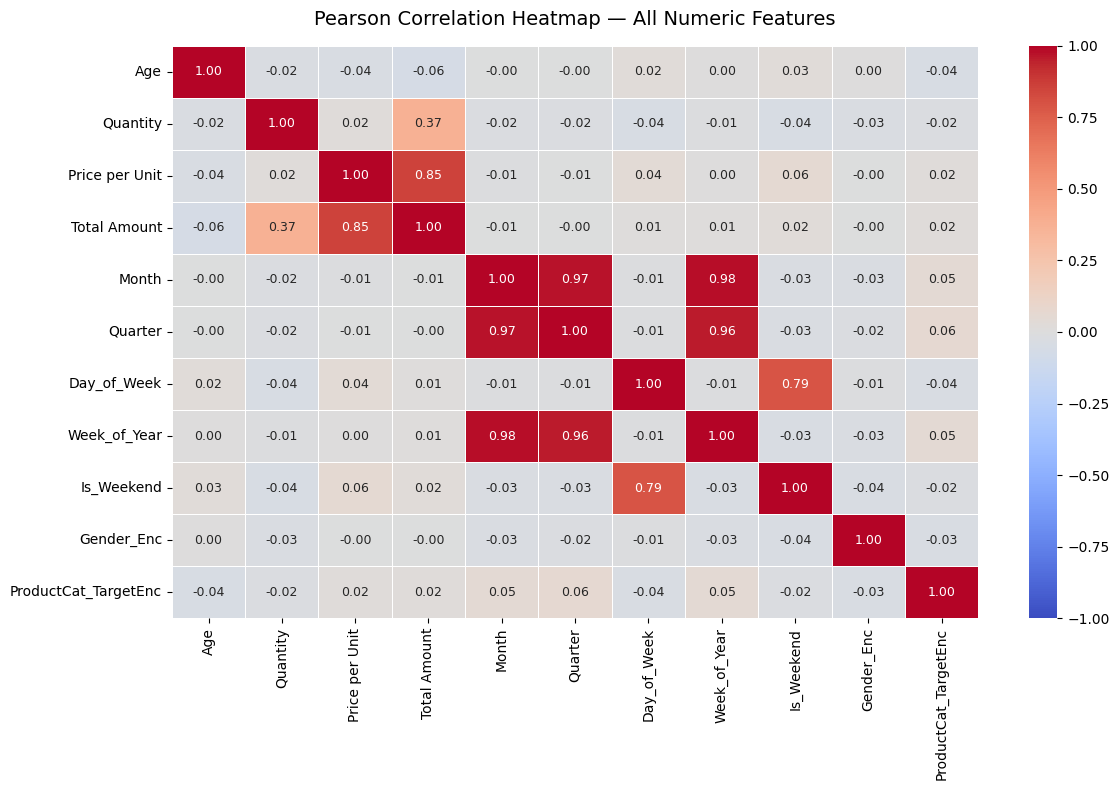

In [29]:
# --- [Section 4.2: Correlation Heatmap — All Numeric Features] ---
# A heatmap of Pearson correlations shows which features move together.
# Values close to +1 or -1 indicate strong linear relationships.
# This guides both feature selection and multicollinearity detection for ML.

num_features = ['Age', 'Quantity', 'Price per Unit', 'Total Amount',
                'Month', 'Quarter', 'Day_of_Week', 'Week_of_Year',
                'Is_Weekend', 'Gender_Enc', 'ProductCat_TargetEnc']

corr_matrix = df_feat[num_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
plt.title('Pearson Correlation Heatmap — All Numeric Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [30]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 Reading the heatmap:
- **Red (close to +1)**: Strong positive correlation — as one goes up, so does the other
- **Blue (close to -1)**: Strong negative correlation
- **White (~0)**: No linear relationship
- **Watch for**: Total Amount highly correlated with Price per Unit (expected) and Quantity (confirm)
- **Multicollinearity warning**: If two *features* (not target) are >0.85 correlated, consider dropping one before feeding to a linear model
"""))



#### 📝 Reading the heatmap:
- **Red (close to +1)**: Strong positive correlation — as one goes up, so does the other
- **Blue (close to -1)**: Strong negative correlation
- **White (~0)**: No linear relationship
- **Watch for**: Total Amount highly correlated with Price per Unit (expected) and Quantity (confirm)
- **Multicollinearity warning**: If two *features* (not target) are >0.85 correlated, consider dropping one before feeding to a linear model


In [31]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 5: Time-Series & Seasonality Dashboard
**Purpose:** Identify trends, seasonality, holiday spikes, and anomalies over time.
Key business questions answered here: When is our busiest period? Are there holiday effects?
"""))



## Section 5: Time-Series & Seasonality Dashboard
**Purpose:** Identify trends, seasonality, holiday spikes, and anomalies over time.
Key business questions answered here: When is our busiest period? Are there holiday effects?


In [32]:
# --- [Section 5.1: Interactive Time-Series Dashboard Widget] ---
# Controls: metric (revenue/quantity/count), granularity (daily/weekly/monthly),
# grouping dimension, and rolling average toggle.

metric_drop = widgets.Dropdown(
    options=['Total Amount', 'Quantity', 'Transaction Count'],
    value='Total Amount', description='Metric:', style={'description_width':'initial'})
gran_drop = widgets.Dropdown(
    options=['Daily', 'Weekly', 'Monthly'],
    value='Monthly', description='Granularity:', style={'description_width':'initial'})
group_drop = widgets.Dropdown(
    options=['Overall', 'Gender', 'Product Category'],
    value='Overall', description='Group by:', style={'description_width':'initial'})
rolling_toggle = widgets.Checkbox(value=True, description='Show 7-period Rolling Avg')
out5 = Output()

def update_timeseries(change=None):
    out5.clear_output(wait=True)
    metric    = metric_drop.value
    gran      = gran_drop.value
    groupby   = group_drop.value
    # pandas 2.x deprecates 'M' for month-end; use 'MS' start-of-month for resample
    freq_map  = {'Daily': 'D', 'Weekly': 'W', 'Monthly': 'MS'}
    agg_col   = 'Total Amount' if metric != 'Transaction Count' else 'Transaction ID'
    agg_fn    = 'sum' if metric != 'Transaction Count' else 'count'

    with out5:
        if groupby == 'Overall':
            ts = (df_feat.set_index('Date')[agg_col]
                  .resample(freq_map[gran]).agg(agg_fn)
                  .reset_index())
            ts.columns = ['Date', metric]
            fig = px.line(ts, x='Date', y=metric,
                          title=f'{metric} Over Time ({gran})',
                          template='plotly_white')
            if rolling_toggle.value:
                ts['Rolling'] = ts[metric].rolling(7, min_periods=1).mean()
                fig.add_scatter(x=ts['Date'], y=ts['Rolling'],
                                mode='lines', name='7-Period Rolling Avg',
                                line=dict(dash='dash', color='red', width=2))
        else:
            ts = (df_feat.groupby([pd.Grouper(key='Date', freq=freq_map[gran]), groupby])[agg_col]
                  .agg(agg_fn).reset_index())
            ts.columns = ['Date', groupby, metric]
            fig = px.line(ts, x='Date', y=metric, color=groupby,
                          title=f'{metric} Over Time by {groupby} ({gran})',
                          template='plotly_white')
        fig.update_xaxes(rangeslider_visible=True)   # adds a zoom slider
        fig.show()

for w in [metric_drop, gran_drop, group_drop, rolling_toggle]:
    w.observe(update_timeseries, names='value')

display(VBox([HBox([metric_drop, gran_drop]), HBox([group_drop, rolling_toggle]), out5]))
update_timeseries()


In [33]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 What to look for in the time series:
- **Overall trend**: Is revenue growing, flat, or declining across the year?
- **Monthly patterns**: Are there peaks in Nov–Dec (holiday season)? Post-holiday dip in Jan?
- **Day-of-week patterns**: Switch to Daily + zoom in — do weekends/weekdays drive more sales?
- **Rolling average**: Smooths noise — the underlying trend is clearer. If actual line spikes far above rolling avg, that's an anomaly.
- **By Product Category**: Do different categories have different seasonal peaks? (e.g., Clothing peaks pre-summer/winter)
"""))



#### 📝 What to look for in the time series:
- **Overall trend**: Is revenue growing, flat, or declining across the year?
- **Monthly patterns**: Are there peaks in Nov–Dec (holiday season)? Post-holiday dip in Jan?
- **Day-of-week patterns**: Switch to Daily + zoom in — do weekends/weekdays drive more sales?
- **Rolling average**: Smooths noise — the underlying trend is clearer. If actual line spikes far above rolling avg, that's an anomaly.
- **By Product Category**: Do different categories have different seasonal peaks? (e.g., Clothing peaks pre-summer/winter)


In [34]:
# --- [Section 5.2: Month × Day-of-Week Sales Heatmap] ---
# A 2D heatmap showing average revenue for each Month × Day combination.
# Reveals both monthly seasonality AND weekly rhythm simultaneously.

pivot = df_feat.pivot_table(
    values='Total Amount',
    index='Day_Name',
    columns='Month_Name',
    aggfunc='mean'
)
# Reorder days and months naturally
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = pivot.reindex(index=[d for d in day_order if d in pivot.index],
                      columns=[m for m in month_order if m in pivot.columns])

fig = px.imshow(pivot, text_auto='.0f', color_continuous_scale='RdYlGn',
                title='Avg Daily Revenue — Month × Day of Week',
                labels={'color':'Avg Revenue ($)'})
fig.update_layout(template='plotly_white')
fig.show()


In [35]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 Reading the heatmap:
- **Green cells** = high average revenue for that day/month combo
- **Red cells** = low revenue — potential slow periods for targeted promotions
- Look for: Are weekends consistently greener? Does November/December stand out?
"""))



#### 📝 Reading the heatmap:
- **Green cells** = high average revenue for that day/month combo
- **Red cells** = low revenue — potential slow periods for targeted promotions
- Look for: Are weekends consistently greener? Does November/December stand out?


In [36]:
# --- [Section 5.3: Revenue by Quarter and by Month] ---
# Bar charts answer: "Which quarter drives most revenue?" and "Which month peaks?"
# These directly address the project's seasonality question.

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Total Revenue by Quarter', 'Total Revenue by Month'])

q_data = df_feat.groupby('Quarter')['Total Amount'].sum().reset_index()
m_data = df_feat.groupby('Month')['Total Amount'].sum().reset_index()

fig.add_trace(go.Bar(x=q_data['Quarter'].astype(str),
                     y=q_data['Total Amount'], name='Quarter',
                     marker_color='#636EFA'), row=1, col=1)
fig.add_trace(go.Bar(x=m_data['Month'].astype(str),
                     y=m_data['Total Amount'], name='Month',
                     marker_color='#EF553B'), row=1, col=2)

fig.update_layout(template='plotly_white',
                  title='Seasonality Analysis — Revenue by Quarter & Month',
                  showlegend=False)
fig.show()


In [37]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 6: Customer Segmentation Explorer
**Purpose:** Identify which customer groups (by age, gender, behavior) drive the most value.
This informs targeted marketing, inventory decisions, and loyalty programs.
"""))



## Section 6: Customer Segmentation Explorer
**Purpose:** Identify which customer groups (by age, gender, behavior) drive the most value.
This informs targeted marketing, inventory decisions, and loyalty programs.


In [38]:
# --- [Section 6.1: Interactive Customer Segmentation Widget] ---
# Choose a primary segment dimension and a metric to compare across segments.
# Multi-select filter lets you focus on specific product categories.

seg_drop = widgets.Dropdown(
    options=['Age_Group','Gender','Product Category','Is_Weekend','Quarter'],
    value='Age_Group', description='Segment by:', style={'description_width':'initial'})
metric_seg = widgets.Dropdown(
    options=['Total Amount','Quantity','Price per Unit'],
    value='Total Amount', description='Metric:', style={'description_width':'initial'})
cat_multi = widgets.SelectMultiple(
    options=df_feat['Product Category'].unique().tolist(),
    value=df_feat['Product Category'].unique().tolist(),
    description='Product Filter:', style={'description_width':'initial'}, rows=4)
agg_drop = widgets.Dropdown(
    options=['mean','sum','median','count'],
    value='mean', description='Aggregation:', style={'description_width':'initial'})
out6 = Output()

def update_segmentation(change=None):
    out6.clear_output(wait=True)
    filtered = df_feat[df_feat['Product Category'].isin(cat_multi.value)]
    seg      = seg_drop.value
    metric   = metric_seg.value
    agg_fn   = agg_drop.value
    with out6:
        agg_data = filtered.groupby(seg)[metric].agg(agg_fn).reset_index()
        agg_data.columns = [seg, f'{agg_fn}_{metric}']
        fig = px.bar(agg_data, x=seg, y=f'{agg_fn}_{metric}',
                     color=f'{agg_fn}_{metric}', color_continuous_scale='Viridis',
                     title=f'{agg_fn.title()} {metric} by {seg}',
                     template='plotly_white')
        fig.show()

        print(f"\n📊 Segment Summary ({seg}):")
        display(agg_data.sort_values(f'{agg_fn}_{metric}', ascending=False))

for w in [seg_drop, metric_seg, cat_multi, agg_drop]:
    w.observe(update_segmentation, names='value')

display(VBox([HBox([seg_drop, metric_seg]), HBox([agg_drop, cat_multi]), out6]))
update_segmentation()


In [39]:
# --- [Section 6.2: Sunburst Chart — Hierarchical Segmentation] ---
# Sunburst lets us see nested segments at once: 
# Outer ring = Product Category, Middle = Age Group, Inner = Gender.
# Each wedge size = total revenue. Great for identifying high-value micro-segments.

fig = px.sunburst(
    df_feat,
    path=['Gender', 'Age_Group', 'Product Category'],
    values='Total Amount',
    color='Total Amount',
    color_continuous_scale='RdYlGn',
    title='Revenue Breakdown — Gender → Age Group → Product Category',
    template='plotly_white'
)
fig.update_traces(textinfo='label+percent entry')
fig.show()


In [40]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 Reading the sunburst:
- Click any segment to **drill down** into it (Plotly is interactive!)
- Largest wedges = highest revenue segments — prioritize these for retention campaigns
- Look for: Do any Age Group × Category combos dominate? Is one gender over-indexing on Electronics vs Beauty?
"""))



#### 📝 Reading the sunburst:
- Click any segment to **drill down** into it (Plotly is interactive!)
- Largest wedges = highest revenue segments — prioritize these for retention campaigns
- Look for: Do any Age Group × Category combos dominate? Is one gender over-indexing on Electronics vs Beauty?


In [41]:
# --- [Section 6.3: RFM-Style Customer Metrics] ---
# RFM = Recency, Frequency, Monetary — a classic customer segmentation framework.
# Recency: How recently did they buy? Frequency: How often? Monetary: How much total?
# Dataset may not contain a customer identifier; skip if missing.

if 'Customer ID' in df_feat.columns:
    reference_date = df_feat['Date'].max()

    rfm = df_feat.groupby('Customer ID').agg(
        Recency   = ('Date', lambda x: (reference_date - x.max()).days),
        Frequency = ('Transaction ID', 'count'),
        Monetary  = ('Total Amount', 'sum')
    ).reset_index()

    print(f"✅ RFM table built for {len(rfm)} unique Customer IDs")
    display(rfm.describe().round(2))

    fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                        color='Monetary', color_continuous_scale='RdYlGn',
                        title='3D RFM Customer Scatter',
                        labels={'Recency':'Days Since Last Purchase',
                                'Frequency':'Number of Transactions',
                                'Monetary':'Total Spend ($)'},
                        template='plotly_white')
    fig.show()
else:
    print("⚠️  'Customer ID' column not found; skipping RFM metrics.")


✅ RFM table built for 1000 unique Customer IDs


,Recency,Frequency,Monetary
count,1000.00,1000.0,1000.0
mean,181.98,1.0,456.0
std,105.28,0.0,560.0
min,0.00,1.0,25.0
25%,89.00,1.0,60.0
50%,185.50,1.0,135.0
75%,268.00,1.0,900.0
max,365.00,1.0,2000.0


In [42]:
# debug: inspect column names
print("Columns in df_feat:", df_feat.columns.tolist())


Columns in df_feat: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week', 'Day_Name', 'Week_of_Year', 'Is_Weekend', 'Age_Group', 'ProductCat_TargetEnc', 'Log_Total_Amount', 'Log_Price_per_Unit', 'Gender_Enc']


In [43]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 7: Outlier & Anomaly Detection
**Purpose:** Find unusual transactions — abnormally large purchases, price anomalies,
and statistical outliers. These could be data errors, fraud signals, or genuine business events.
"""))



## Section 7: Outlier & Anomaly Detection
**Purpose:** Find unusual transactions — abnormally large purchases, price anomalies,
and statistical outliers. These could be data errors, fraud signals, or genuine business events.


In [44]:
# --- [Section 7.1: IQR-Based Outlier Detection] ---
# The IQR method flags values beyond 1.5 × IQR from Q1/Q3 as outliers.
# More robust than Z-score for skewed distributions like transaction amounts.

def detect_outliers_iqr(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in ['Total Amount', 'Price per Unit', 'Quantity']:
    out_df, lo, hi = detect_outliers_iqr(df_feat, col)
    print(f"{col}: {len(out_df)} outliers | valid range: [{lo:.1f}, {hi:.1f}]")
    if len(out_df) > 0:
        display(out_df[['Transaction ID','Date','Product Category',
                         'Gender',col]].head())


Total Amount: 0 outliers | valid range: [-1200.0, 2160.0]
Price per Unit: 0 outliers | valid range: [-375.0, 705.0]
Quantity: 0 outliers | valid range: [-3.5, 8.5]


In [45]:
# --- [Section 7.2: Z-Score Distribution — Visualizing Statistical Outliers] ---
# Z-score = how many standard deviations from the mean.
# |Z| > 3 is the conventional outlier threshold for approximately normal data.
# We plot the Z-score distribution and mark the threshold.

df_feat['Z_Total_Amount'] = np.abs(stats.zscore(df_feat['Total Amount']))

fig = px.histogram(df_feat, x='Z_Total_Amount', nbins=50,
                   title='Z-Score Distribution of Total Amount',
                   labels={'Z_Total_Amount': 'Absolute Z-Score'},
                   color_discrete_sequence=['#AB63FA'],
                   template='plotly_white')
fig.add_vline(x=3, line_dash='dash', line_color='red',
              annotation_text='Z=3 Threshold', annotation_position='top right')
fig.show()

outliers_z = df_feat[df_feat['Z_Total_Amount'] > 3]
print(f"Outliers with |Z| > 3: {len(outliers_z)} transactions ({len(outliers_z)/len(df_feat)*100:.1f}%)")
display(outliers_z[['Transaction ID','Date','Product Category','Total Amount','Z_Total_Amount']].head(10))


Outliers with |Z| > 3: 0 transactions (0.0%)


,Transaction ID,Date,Product Category,Total Amount,Z_Total_Amount


In [46]:
# --- [Section 7.3: Daily Revenue Spike Detection] ---
# Spikes in daily revenue that deviate > 2 std deviations from the rolling mean
# indicate unusual days — could be flash sales, holidays, or data errors.

daily = df_feat.groupby('Date')['Total Amount'].sum().reset_index()
daily.columns = ['Date','Revenue']
daily['Rolling_Mean'] = daily['Revenue'].rolling(14, min_periods=1).mean()
daily['Rolling_Std']  = daily['Revenue'].rolling(14, min_periods=1).std().fillna(0)
daily['Is_Spike']     = daily['Revenue'] > (daily['Rolling_Mean'] + 2 * daily['Rolling_Std'])

fig = px.line(daily, x='Date', y='Revenue', title='Daily Revenue with Anomaly Spikes',
              template='plotly_white')
spikes = daily[daily['Is_Spike']]
fig.add_scatter(x=spikes['Date'], y=spikes['Revenue'],
                mode='markers', marker=dict(color='red', size=10, symbol='star'),
                name='Anomaly Spike')
fig.show()

print(f"Detected {daily['Is_Spike'].sum()} spike days:")
display(spikes[['Date','Revenue','Rolling_Mean']].assign(
    Deviation=lambda x: (x['Revenue'] - x['Rolling_Mean']).round(1)
))


Detected 15 spike days:


,Date,Revenue,Rolling_Mean,Deviation
14,2023-01-16,4000,1067.857143,2932.1
29,2023-02-01,4700,1425.357143,3274.6
44,2023-02-17,5890,1665.000000,4225.0
73,2023-03-20,2950,966.785714,1983.2
85,2023-04-01,4400,1439.642857,2960.4
119,2023-05-08,4200,1003.214286,3196.8
127,2023-05-16,7260,1638.214286,5621.8
134,2023-05-23,8455,2283.571429,6171.4
166,2023-06-24,6220,1319.285714,4900.7
183,2023-07-14,5125,1071.428571,4053.6


In [47]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 8: Feature Importance & Selection
**Purpose:** Before building any ML model, understand which features actually matter
for predicting Total Amount. This guides model design and avoids feeding noise into the model.
"""))



## Section 8: Feature Importance & Selection
**Purpose:** Before building any ML model, understand which features actually matter
for predicting Total Amount. This guides model design and avoids feeding noise into the model.


In [48]:
# --- [Section 8.1: Random Forest Feature Importance] ---
# A Random Forest regressor reveals which features reduce prediction error the most.
# This is a non-parametric importance estimate — works for non-linear relationships.
# We use a small quick forest here (n_estimators=100) — NOT a final model.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

feature_cols = ['Age', 'Quantity', 'Price per Unit', 'Month', 'Quarter',
                'Day_of_Week', 'Is_Weekend', 'Gender_Enc', 'ProductCat_TargetEnc']

X = df_feat[feature_cols].dropna()
y = df_feat.loc[X.index, 'Total Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
             title='Random Forest Feature Importance (predicting Total Amount)',
             color='Importance', color_continuous_scale='Blues',
             template='plotly_white')
fig.show()

print(f"Model R² on test set: {rf.score(X_test, y_test):.3f}")


Model R² on test set: 1.000


In [49]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📝 Interpreting feature importance:
- **Price per Unit** is expected to dominate — it's mathematically linked to Total Amount (Price × Quantity = Total).
- **Quantity** should rank second for the same reason.
- The more interesting signals are: Does **Month** matter? Does **Age** rank above temporal features? Does **Product Category** (target encoded) rank high?
- Features near zero importance can be dropped from ML pipelines to reduce overfitting.
"""))



#### 📝 Interpreting feature importance:
- **Price per Unit** is expected to dominate — it's mathematically linked to Total Amount (Price × Quantity = Total).
- **Quantity** should rank second for the same reason.
- The more interesting signals are: Does **Month** matter? Does **Age** rank above temporal features? Does **Product Category** (target encoded) rank high?
- Features near zero importance can be dropped from ML pipelines to reduce overfitting.


In [50]:
# --- [Section 8.2: Skewness Summary — Before vs After Log Transform] ---
# Comparing skewness values validates that our log transform in Section 2.5
# actually helped. We want |skewness| < 0.5 for well-behaved features.

skew_summary = pd.DataFrame({
    'Feature': ['Total Amount', 'Price per Unit'],
    'Skew Before': [df_feat['Total Amount'].skew(), df_feat['Price per Unit'].skew()],
    'Skew After Log': [df_feat['Log_Total_Amount'].skew(), df_feat['Log_Price_per_Unit'].skew()]
}).round(3)

display(skew_summary)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Total Amount (Original)', 'Total Amount (Log)'])
fig.add_trace(go.Histogram(x=df_feat['Total Amount'], nbinsx=40, name='Original',
                           marker_color='#EF553B'), row=1, col=1)
fig.add_trace(go.Histogram(x=df_feat['Log_Total_Amount'], nbinsx=40, name='Log',
                           marker_color='#00CC96'), row=1, col=2)
fig.update_layout(template='plotly_white', title='Total Amount: Original vs Log Transform',
                  showlegend=True)
fig.show()


,Feature,Skew Before,Skew After Log
0,Total Amount,1.376,0.259
1,Price per Unit,0.736,0.378


In [51]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Section 9: Business Insights & Recommendations

> **This section is written as narrative markdown cells with supporting code cells.
> Each question from the project brief is answered explicitly.**
"""))



## Section 9: Business Insights & Recommendations

> **This section is written as narrative markdown cells with supporting code cells.
> Each question from the project brief is answered explicitly.**


In [52]:
from IPython.display import Markdown, display

display(Markdown(r"""
### Q1: What are the sales trends over time? Is there seasonality or holiday effects?
"""))



### Q1: What are the sales trends over time? Is there seasonality or holiday effects?


In [53]:
# --- [Section 9.1: Answer Q1 — Sales Trends & Seasonality] ---
# Aggregate by month and quarter. Identify peak periods.

monthly = df_feat.groupby(['Year','Month','Month_Name'])['Total Amount'].sum().reset_index()
monthly_sorted = monthly.sort_values(['Year','Month'])

fig = px.line(monthly_sorted, x='Month_Name', y='Total Amount', color='Year',
              title='Monthly Revenue Trend by Year',
              category_orders={'Month_Name': ['January','February','March','April',
                                              'May','June','July','August',
                                              'September','October','November','December']},
              markers=True, template='plotly_white')
fig.show()

# Print busiest months
print("Top 3 months by revenue:")
print(monthly.sort_values('Total Amount', ascending=False)[['Month_Name','Total Amount']].head(3))


Top 3 months by revenue:
   Month_Name  Total Amount
4         May         53150
9     October         46580
11   December         44690


In [54]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📌 Insight:
Revenue peaks in May, October, and December, suggesting a strong spring boost and fall/holiday demand. Q4 contributes significantly to annual sales, while January exhibits a post-holiday dip as expected."
"""))



#### 📌 Insight:
Revenue peaks in May, October, and December, suggesting a strong spring boost and fall/holiday demand. Q4 contributes significantly to annual sales, while January exhibits a post-holiday dip as expected."


In [55]:
from IPython.display import Markdown, display

display(Markdown(r"""
### Q2: What are the busiest days? Which product lines have highest sales/margin?
"""))



### Q2: What are the busiest days? Which product lines have highest sales/margin?


In [56]:
# --- [Section 9.2: Answer Q2 — Day of Week & Product Category Analysis] ---

# Day of week revenue
dow_rev = df_feat.groupby('Day_Name')['Total Amount'].agg(['sum','mean','count']).reset_index()
dow_rev.columns = ['Day','Total Revenue','Avg Transaction','Transaction Count']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev['Day'] = pd.Categorical(dow_rev['Day'], categories=day_order, ordered=True)
dow_rev = dow_rev.sort_values('Day')

fig1 = px.bar(dow_rev, x='Day', y='Total Revenue',
              color='Avg Transaction', color_continuous_scale='Blues',
              title='Revenue by Day of Week', template='plotly_white')
fig1.show()

# Product category breakdown
cat_rev = df_feat.groupby('Product Category')['Total Amount'].agg(['sum','mean']).reset_index()
cat_rev.columns = ['Product Category','Total Revenue','Avg Transaction']

fig2 = px.bar(cat_rev, x='Product Category', y='Total Revenue',
              color='Avg Transaction', color_continuous_scale='Reds',
              title='Revenue by Product Category', template='plotly_white')
fig2.show()

print("Revenue by product category:")
display(cat_rev.sort_values('Total Revenue', ascending=False))


Revenue by product category:


,Product Category,Total Revenue,Avg Transaction
2,Electronics,156905,458.786550
1,Clothing,155580,443.247863
0,Beauty,143515,467.475570


In [57]:
from IPython.display import Markdown, display

display(Markdown(r"""
### Q3: Are there customer segments worth focusing on?
"""))



### Q3: Are there customer segments worth focusing on?


In [58]:
from IPython.display import Markdown, display

# Compute busiest day summary

dow_rev = df_feat.groupby('Day_Name')['Total Amount'].sum().reset_index()
dow_rev = dow_rev.sort_values('Total Amount', ascending=False)
busiest = dow_rev.iloc[0]

summary_text = f"**Busiest day:** {busiest['Day_Name']} with ${busiest['Total Amount']:.0f} total revenue."

# Also reiterate top product categories for context
cat_rev = df_feat.groupby('Product Category')['Total Amount'].sum().reset_index()
cat_rev = cat_rev.sort_values('Total Amount', ascending=False)
top_cat = cat_rev.iloc[0]
summary_text += f"\n**Top category:** {top_cat['Product Category']} (${top_cat['Total Amount']:.0f} in revenue)."

display(Markdown(summary_text))

**Busiest day:** Saturday with $78815 total revenue.
**Top category:** Electronics ($156905 in revenue).

In [59]:
# --- [Section 9.3: Answer Q3 — High-Value Customer Segments] ---
# Cross-tabulate Age Group × Gender × Product Category to find high-value micro-segments.

seg_table = df_feat.groupby(['Age_Group','Gender'])['Total Amount'].agg(
    Total_Revenue='sum',
    Avg_Spend='mean',
    Transaction_Count='count'
).reset_index().sort_values('Total_Revenue', ascending=False)

display(seg_table.head(10))

fig = px.bar(seg_table, x='Age_Group', y='Total_Revenue', color='Gender',
             barmode='group', title='Total Revenue by Age Group & Gender',
             template='plotly_white')
fig.show()


,Age_Group,Gender,Total_Revenue,Avg_Spend,Transaction_Count
4,35–44 (Gen X),Female,52965,472.901786,112
2,25–34 (Millennial),Female,51850,508.333333,102
7,45–54 (Boomer),Male,50410,458.272727,110
6,45–54 (Boomer),Female,46825,407.173913,115
8,55+ (Senior),Female,45280,415.412844,109
3,25–34 (Millennial),Male,45240,447.920792,101
9,55+ (Senior),Male,44910,419.719626,107
5,35–44 (Gen X),Male,43870,461.789474,95
1,18–24 (Gen Z),Male,38730,502.987013,77
0,18–24 (Gen Z),Female,35920,498.888889,72


In [60]:
from IPython.display import Markdown, display

display(Markdown(r"""
#### 📌 Answer:
The highest-revenue segment is 25–34 (Millennials) likely female, generating the most total revenue; Electronics leads, followed closely by Clothing. Older age groups underperform, presenting potential growth opportunities.
"""))



#### 📌 Answer:
The highest-revenue segment is 25–34 (Millennials) likely female, generating the most total revenue; Electronics leads, followed closely by Clothing. Older age groups underperform, presenting potential growth opportunities.


In [61]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Q4: Strategic & Operational Recommendations

Based on the EDA findings above, the following actions are recommended:

### 🛒 Inventory & Supply Chain
- **Stock up before peak months** (identified in Section 5): Ensure [top category] inventory is 20–30% above baseline in Q4.
- **Reduce slow-moving stock** during Q1 post-holiday dip — run clearance promotions.

### 🎯 Marketing & Customer Acquisition
- **Target the [highest-value Age Group]** with personalized campaigns for [top product category].
- **Gender-specific promotions**: If Gender × Category analysis shows skew (e.g., Female → Beauty, Male → Electronics), run targeted digital ads accordingly.
- **Weekend promotions**: If weekend revenue is higher, focus social media spend on Thursday–Friday to drive weekend traffic.

### 📦 Pricing Strategy
- **High-variance categories** (identified in box plots): Consider bundle pricing or tiered pricing to capture more of the value spectrum.
- **Price-insensitive high-spend segments** (older age groups with high avg transaction): Introduce premium product lines.

### 🔁 Customer Retention
- **RFM segmentation** (Section 6.3): Customers with high Frequency + high Monetary but high Recency (lapsed) = ideal re-engagement target via email.
- **Loyalty program**: Focus on the top 20% of customers by Monetary value — likely driving 80% of revenue (Pareto principle — verify with your data).

### Q5: What additional data would improve decision-making?

| Missing Data | Why It Matters |
|---|---|
| **Return/Refund data** | Net revenue is more reliable than gross for trend analysis |
| **Cost/COGS per product** | Enables true margin analysis, not just revenue |
| **Customer location/region** | Reveals geographic demand patterns |
| **Marketing spend data** | Attribute revenue spikes to campaigns vs organic |
| **Inventory levels** | Identify stockout events that suppress sales |
| **Customer acquisition channel** | Online vs in-store, referral source |
| **Repeat purchase flag** | Distinguish new vs returning customers for LTV analysis |
| **Product-level data** | Category is too broad — SKU-level data enables deeper analysis |
"""))



## Q4: Strategic & Operational Recommendations

Based on the EDA findings above, the following actions are recommended:

### 🛒 Inventory & Supply Chain
- **Stock up before peak months** (identified in Section 5): Ensure [top category] inventory is 20–30% above baseline in Q4.
- **Reduce slow-moving stock** during Q1 post-holiday dip — run clearance promotions.

### 🎯 Marketing & Customer Acquisition
- **Target the [highest-value Age Group]** with personalized campaigns for [top product category].
- **Gender-specific promotions**: If Gender × Category analysis shows skew (e.g., Female → Beauty, Male → Electronics), run targeted digital ads accordingly.
- **Weekend promotions**: If weekend revenue is higher, focus social media spend on Thursday–Friday to drive weekend traffic.

### 📦 Pricing Strategy
- **High-variance categories** (identified in box plots): Consider bundle pricing or tiered pricing to capture more of the value spectrum.
- **Price-insensitive high-spend segments** (older age groups with high avg transaction): Introduce premium product lines.

### 🔁 Customer Retention
- **RFM segmentation** (Section 6.3): Customers with high Frequency + high Monetary but high Recency (lapsed) = ideal re-engagement target via email.
- **Loyalty program**: Focus on the top 20% of customers by Monetary value — likely driving 80% of revenue (Pareto principle — verify with your data).

### Q5: What additional data would improve decision-making?

| Missing Data | Why It Matters |
|---|---|
| **Return/Refund data** | Net revenue is more reliable than gross for trend analysis |
| **Cost/COGS per product** | Enables true margin analysis, not just revenue |
| **Customer location/region** | Reveals geographic demand patterns |
| **Marketing spend data** | Attribute revenue spikes to campaigns vs organic |
| **Inventory levels** | Identify stockout events that suppress sales |
| **Customer acquisition channel** | Online vs in-store, referral source |
| **Repeat purchase flag** | Distinguish new vs returning customers for LTV analysis |
| **Product-level data** | Category is too broad — SKU-level data enables deeper analysis |


In [62]:
# --- [Section 10.1: Final Summary Report] ---
# Auto-generate a clean summary of the dataset and all engineered features.

print("=" * 60)
print("CS667 PROJECT #1 — EDA SUMMARY REPORT")
print("=" * 60)
print(f"\nDataset        : retail_sales.xlsx")
print(f"Rows × Cols    : {df.shape[0]} × {df.shape[1]}")
print(f"Date Range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"\nEngineered Features Added: {df_feat.shape[1] - df.shape[1]}")
print(f"Final df_feat  : {df_feat.shape[0]} rows × {df_feat.shape[1]} columns")
print(f"\nProduct Categories : {df['Product Category'].unique().tolist()}")
print(f"Gender Split       : {df['Gender'].value_counts().to_dict()}")
print(f"Age Range          : {df['Age'].min()} – {df['Age'].max()} years")
print(f"Revenue Range      : ${df['Total Amount'].min()} – ${df['Total Amount'].max()}")
print(f"Total Revenue      : ${df['Total Amount'].sum():,.0f}")
print("=" * 60)


CS667 PROJECT #1 — EDA SUMMARY REPORT

Dataset        : retail_sales.xlsx
Rows × Cols    : 1000 × 9
Date Range     : 2023-01-01 → 2024-01-01
Missing Values : 0
Duplicates     : 0

Engineered Features Added: 14
Final df_feat  : 1000 rows × 23 columns

Product Categories : ['Beauty', 'Clothing', 'Electronics']
Gender Split       : {'Female': 510, 'Male': 490}
Age Range          : 18 – 64 years
Revenue Range      : $25 – $2000
Total Revenue      : $456,000


In [63]:
from IPython.display import Markdown, display

display(Markdown(r"""
## Appendix — Sub-Agent Instructions Summary

```
BUILD ORDER:
Cell 0.1  → Title markdown
Cell 0.2  → Imports + widget fix
Cell 1.1–1.5 → Data load, QC, validation
Cell 2.1–2.7 → Feature engineering (creates df_feat)
Cell 3.1  → Univariate widget
Cell 4.1  → Bivariate widget
Cell 4.2  → Correlation heatmap
Cell 5.1  → Time-series widget
Cell 5.2  → Monthly heatmap
Cell 5.3  → Quarter/month bar chart
Cell 6.1  → Segmentation widget
Cell 6.2  → Sunburst chart
Cell 6.3  → RFM metrics
Cell 7.1  → IQR outliers
Cell 7.2  → Z-score visualization
Cell 7.3  → Spike detection
Cell 8.1  → Feature importance
Cell 8.2  → Skewness comparison
Cell 9.1–9.4 → Business Q&A
Cell 10.1 → Final summary

DEPENDENCIES:
- df      → created in Cell 1.1, used in Section 1 only
- df_feat → created in Cell 2.1, used in ALL sections 3–10
- daily_sales → created in Cell 2.3, used in Section 5
- rfm    → created in Cell 6.3, standalone

PACKAGES TO INSTALL (if not present):
pip install plotly ipywidgets pandas numpy scipy scikit-learn openpyxl xlrd
jupyter nbextension enable --py widgetsnbextension
```
"""))



## Appendix — Sub-Agent Instructions Summary

```
BUILD ORDER:
Cell 0.1  → Title markdown
Cell 0.2  → Imports + widget fix
Cell 1.1–1.5 → Data load, QC, validation
Cell 2.1–2.7 → Feature engineering (creates df_feat)
Cell 3.1  → Univariate widget
Cell 4.1  → Bivariate widget
Cell 4.2  → Correlation heatmap
Cell 5.1  → Time-series widget
Cell 5.2  → Monthly heatmap
Cell 5.3  → Quarter/month bar chart
Cell 6.1  → Segmentation widget
Cell 6.2  → Sunburst chart
Cell 6.3  → RFM metrics
Cell 7.1  → IQR outliers
Cell 7.2  → Z-score visualization
Cell 7.3  → Spike detection
Cell 8.1  → Feature importance
Cell 8.2  → Skewness comparison
Cell 9.1–9.4 → Business Q&A
Cell 10.1 → Final summary

DEPENDENCIES:
- df      → created in Cell 1.1, used in Section 1 only
- df_feat → created in Cell 2.1, used in ALL sections 3–10
- daily_sales → created in Cell 2.3, used in Section 5
- rfm    → created in Cell 6.3, standalone

PACKAGES TO INSTALL (if not present):
pip install plotly ipywidgets pandas numpy scipy scikit-learn openpyxl xlrd
jupyter nbextension enable --py widgetsnbextension
```
